#### Project Summary - Home Loan Prediction
This project helps build a deeper understanding of classification problems with an imbalanced dataset. The objective is to create a model that predicts whether an applicant will be able to repay a loan using historical data.

Domain: Finance

I am using the [HMEQ dataset](https://www.kaggle.com/datasets/ajay1735/hmeq-data?resource=download) downloaded from Kaggle. This is a binary classification problem with a roughly 80/20 class imbalance. An Artificial Neural Network (ANN) model will be trained to make the predictions and will be compared against a baseline model. 

## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Core
import numpy as np
import pandas as pd
from pathlib import Path
import os
import random

# Train/Test Split, Scaling, Encoding, Imputation
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Class Imbalance
from sklearn.utils.class_weight import compute_class_weight

# Baseline Model
from sklearn.linear_model import LogisticRegression

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from keras import regularizers, layers
from keras.callbacks import EarlyStopping
from keras.layers import Dropout, BatchNormalization

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

# Visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

I0000 00:00:1782186825.898904  156218 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782186825.902273  156218 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782186826.241051  156218 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782186829.695100  156218 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

## Loading Data

In [2]:
DATA_PATH = Path('../data/raw/hmeq.csv')
df = pd.read_csv(DATA_PATH).copy()

df.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [3]:
# General Inspection
df.info()
print('Shape of the dataset:', df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   str    
 5   JOB      5681 non-null   str    
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), str(2)
memory usage: 605.4 KB
Shape of the dataset: (5960, 13)


## Data Preprocessing

In [4]:
# Checking Missing Values and Duplicates
print('Missing values per column:\n')
print(df.isnull().sum())
print('\nNumber of duplicate rows:', df.duplicated().sum())

Missing values per column:

BAD           0
LOAN          0
MORTDUE     518
VALUE       112
REASON      252
JOB         279
YOJ         515
DEROG       708
DELINQ      580
CLAGE       308
NINQ        510
CLNO        222
DEBTINC    1267
dtype: int64

Number of duplicate rows: 0


## EDA

Class Counts:
BAD
0    4771
1    1189
Name: count, dtype: int64

Class Percentages:
BAD
0    80.050336
1    19.949664
Name: proportion, dtype: float64



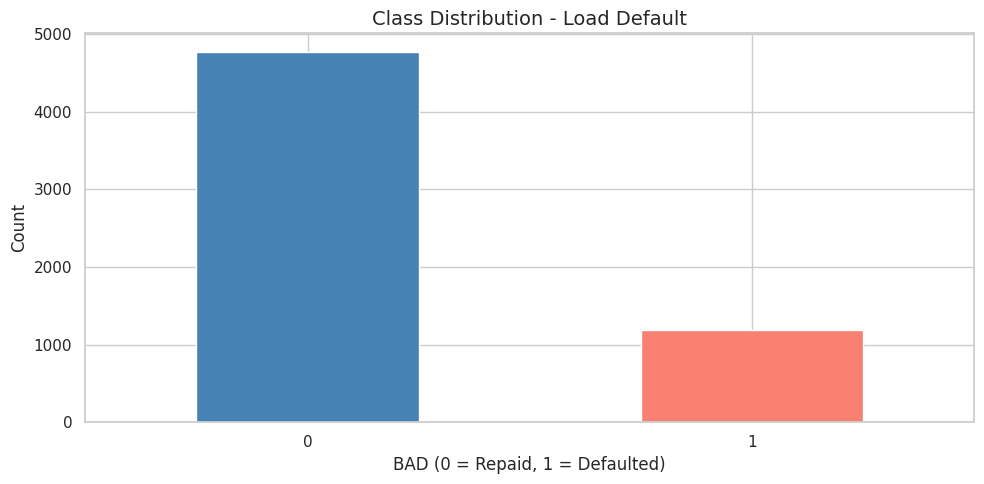

In [ ]:
# Bar Plot Of Class Distribution
counts = df["BAD"].value_counts().sort_index()
percentages = target_counts = df['BAD'].value_counts(normalize=True).sort_index() * 100


print("Class Counts:")
print(counts)
print("\nClass Percentages:")
print(percentages.round(2))

counts.plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Class Distribution - Load Default')
plt.xlabel('BAD (0 = Repaid, 1 = Defaulted)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()